In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

Data Presentation

In [ ]:
print(X.head())

print(X.info())

print(X.describe())

   displacement  cylinders  horsepower  weight  acceleration  model_year  \
0         307.0          8       130.0    3504          12.0          70   
1         350.0          8       165.0    3693          11.5          70   
2         318.0          8       150.0    3436          11.0          70   
3         304.0          8       150.0    3433          12.0          70   
4         302.0          8       140.0    3449          10.5          70   

   origin  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 

2.1 Exploratory Data Analysis

Step 1: Checking for Missing Values




In [ ]:
import pandas as pd

df = pd.concat([X, y], axis=1)

missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])

horsepower    6
dtype: int64


Step 2: Distribution of the target variable (MPG)

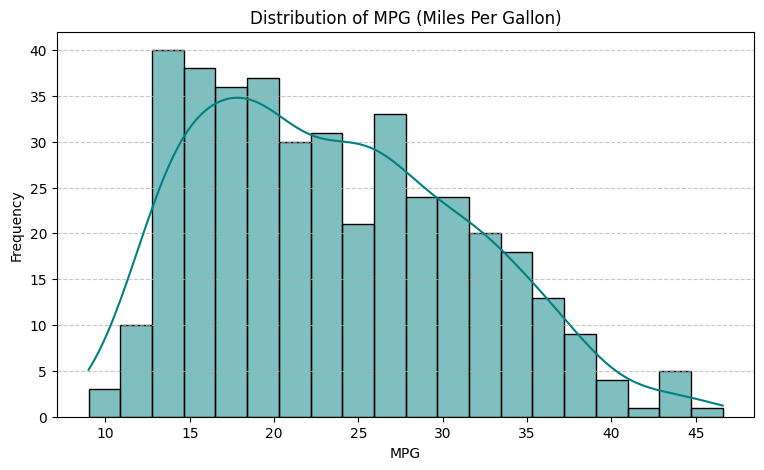

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# (KDE)
plt.figure(figsize=(9, 5))
sns.histplot(df['mpg'], kde=True, color='teal', bins=20)
plt.title('Distribution of MPG (Miles Per Gallon)')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Step 3: Relationships between individual features and the target

1. Analysis of Continuous Variables($mpg$)

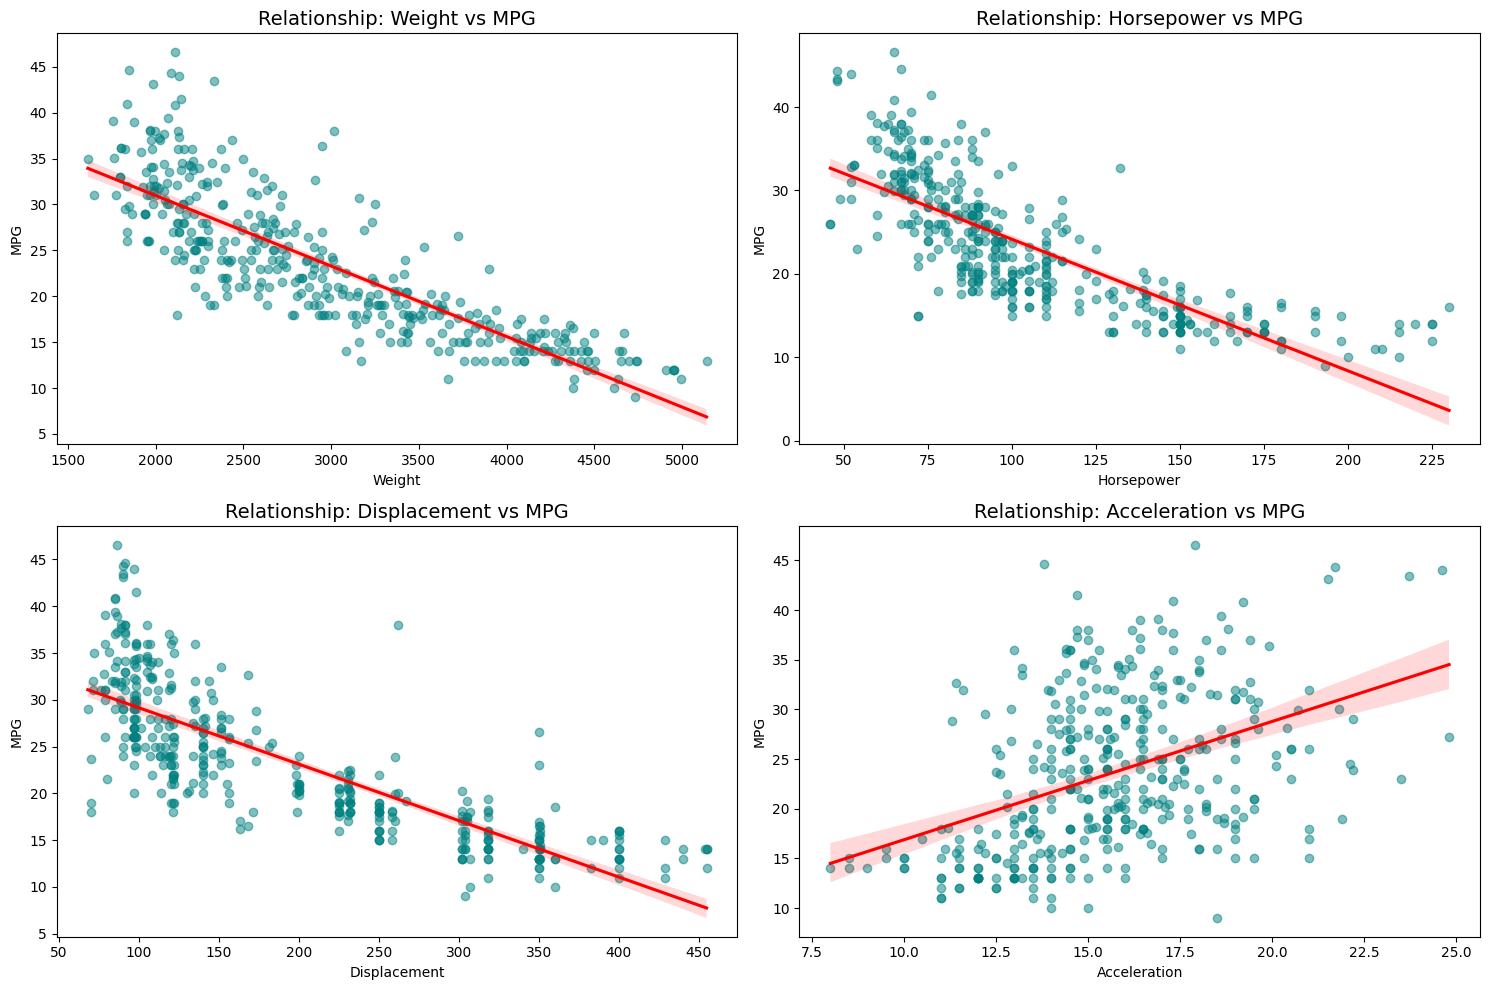

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_features = ['weight', 'horsepower', 'displacement', 'acceleration']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):

    sns.regplot(data=df, x=col, y='mpg', ax=axes[i],
                scatter_kws={'alpha':0.5, 'color':'teal'},
                line_kws={'color':'red'})

    axes[i].set_title(f'Relationship: {col.capitalize()} vs MPG', fontsize=14)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('MPG')

plt.tight_layout()
plt.show()

2. Analysis of Discrete and Categorical Variables ($mpg$)

/tmp/ipykernel_228/3594894551.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='mpg', ax=axes[i], palette='viridis')
/tmp/ipykernel_228/3594894551.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='mpg', ax=axes[i], palette='viridis')
/tmp/ipykernel_228/3594894551.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='mpg', ax=axes[i], palette='viridis')


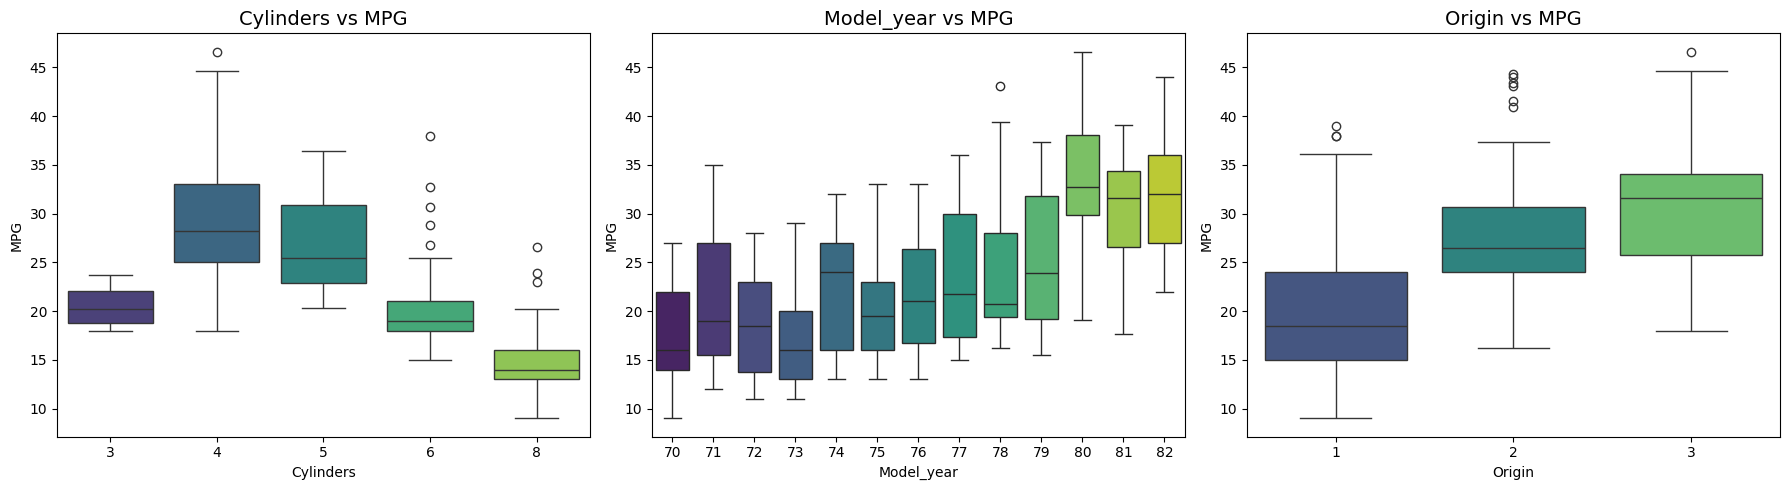

In [ ]:
discrete_features = ['cylinders', 'model_year', 'origin']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(discrete_features):

    sns.boxplot(data=df, x=col, y='mpg', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col.capitalize()} vs MPG', fontsize=14)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('MPG')

plt.tight_layout()
plt.show()


Step 4: Correlations Between Features

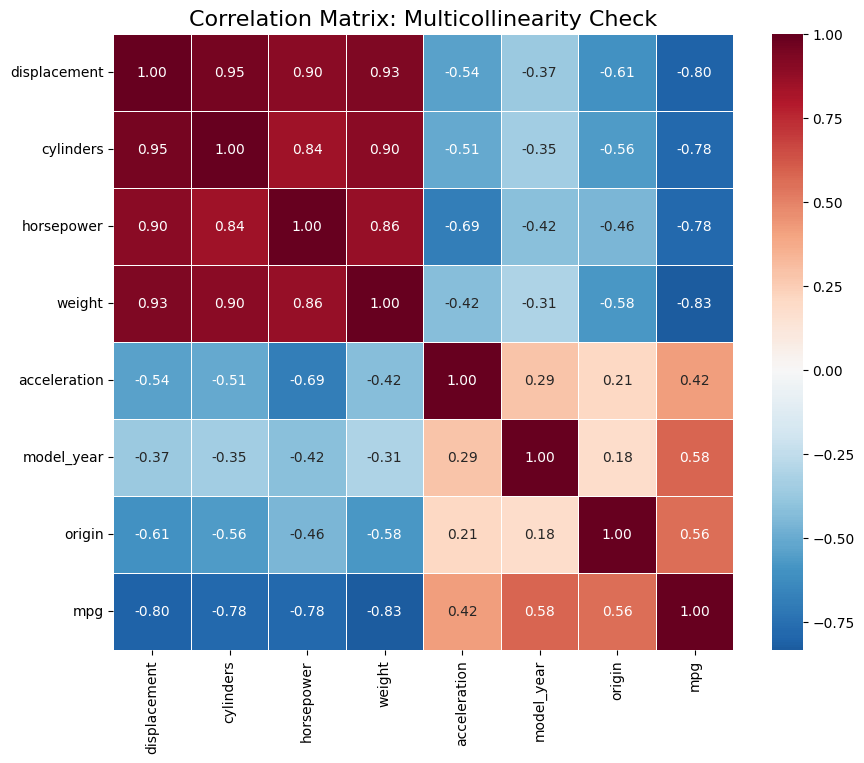

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", center=0, linewidths=0.5)

plt.title('Correlation Matrix: Multicollinearity Check', fontsize=16)
plt.show()

 2.2 Dataset and Preprocessing

Step 1: Feature Selection and Initial Handling

In [ ]:
import numpy as np
import pandas as pd

df = pd.concat([X, y], axis=1)

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

print("Missing values per column:\n", df.isnull().sum())

horsepower_median = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(horsepower_median)

if 'car_name' in df.columns:
    df = df.drop(columns=['car_name'])

print("\nData cleaned. Final columns:", df.columns.tolist())
print(f"Used median for horsepower: {horsepower_median}")

Missing values per column:
 displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

Data cleaned. Final columns: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']
Used median for horsepower: 93.5


Step 2: Missing Values and Imputation

In [ ]:
import pandas as pd
import numpy as np

df = pd.concat([X, y], axis=1)

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

hp_median = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(hp_median)

if 'car_name' in df.columns:
    df = df.drop(columns=['car_name'])

print(f"Missing values post-processing:\n{df.isnull().sum()}")
print(f"\nThe median selected for filling Horsepower: {hp_median}")

ערכים חסרים לאחר טיפול:
displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

החציון שנבחר למילוי horsepower: 93.5


Step3: Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('mpg', axis=1), df['mpg'], test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Standardization complete. Mean of features is now approximately 0 and Std is 1.")

Standardization complete. Mean of features is now approximately 0 and Std is 1.


2.3 Linear Regression Baseline

Step 1: Model Training and Performance Evaluation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # התיקון כאן
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.2f}")

MSE: 8.20
RMSE: 2.86
MAE: 2.26
R^2: 0.85


Feature-Target Relationship Plots:

Prediction vs. Ground Truth and MPG vs.Weight

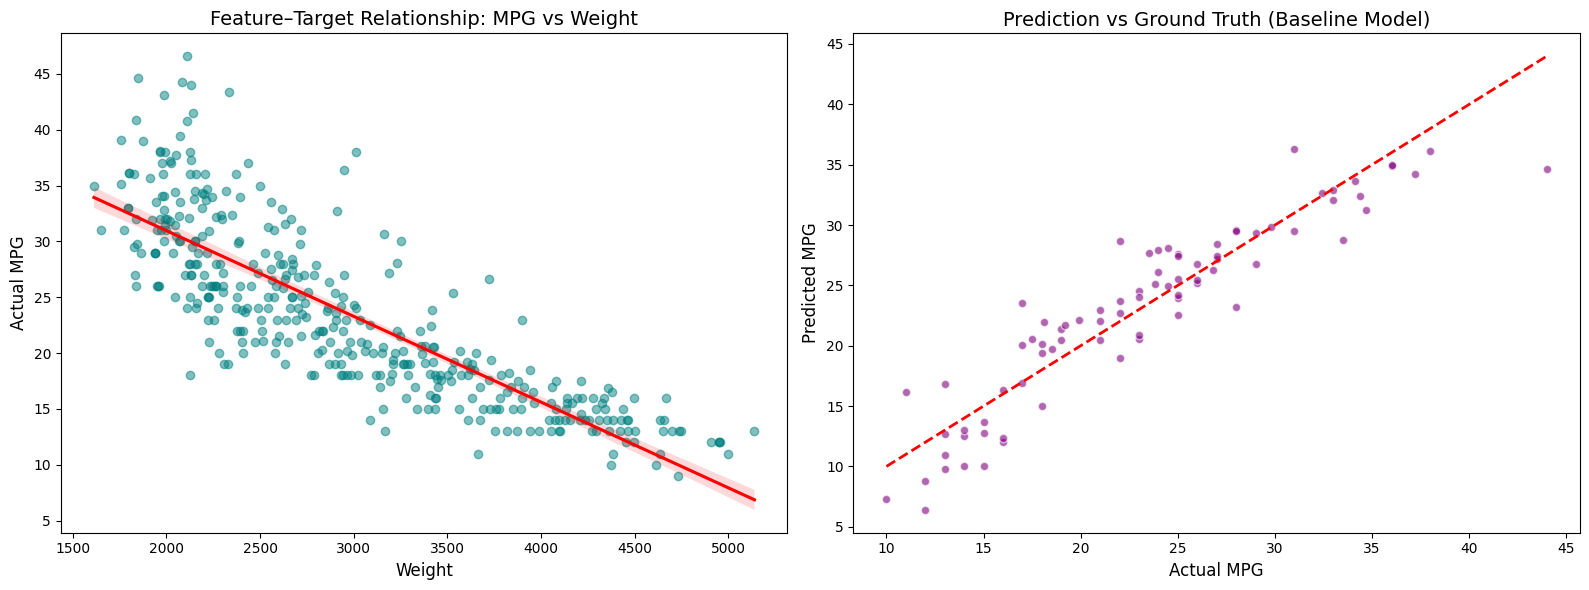

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='weight', y='mpg', ax=ax1,
            scatter_kws={'alpha':0.5, 'color':'teal'},
            line_kws={'color':'red'})
ax1.set_title('Feature–Target Relationship: MPG vs Weight', fontsize=14)
ax1.set_xlabel('Weight', fontsize=12)
ax1.set_ylabel('Actual MPG', fontsize=12)

ax2.scatter(y_test, y_pred, alpha=0.6, color='purple', edgecolors='w')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_title('Prediction vs Ground Truth (Baseline Model)', fontsize=14)
ax2.set_xlabel('Actual MPG', fontsize=12)
ax2.set_ylabel('Predicted MPG', fontsize=12)

plt.tight_layout()
plt.show()

2.4 Polynomial Regression and Model Complexity

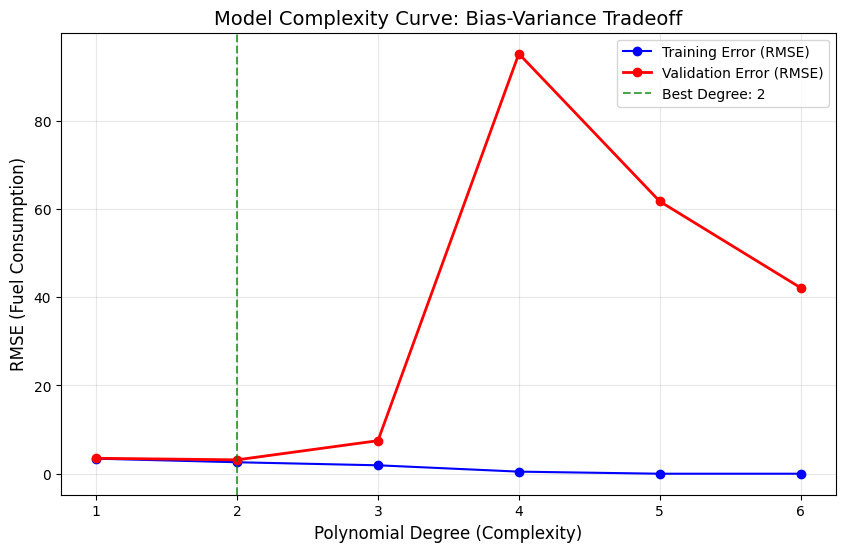

הדרגה שנבחרה היא: 2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

degrees = range(1, 7)
train_rmse_list = []
validation_rmse_list = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly_train = poly.fit_transform(X_train_scaled)

    model = LinearRegression()

    neg_mse_scores = cross_val_score(model, X_poly_train, y_train,
                                     scoring='neg_mean_squared_error', cv=5)
    val_rmse = np.sqrt(-neg_mse_scores.mean())
    validation_rmse_list.append(val_rmse)

    model.fit(X_poly_train, y_train)
    train_pred = model.predict(X_poly_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_rmse_list.append(train_rmse)

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_rmse_list, 'o-', label='Training Error (RMSE)', color='blue')
plt.plot(degrees, validation_rmse_list, 'o-', label='Validation Error (RMSE)', color='red', linewidth=2)

best_degree = degrees[np.argmin(validation_rmse_list)]
plt.axvline(best_degree, linestyle='--', color='green', alpha=0.7, label=f'Best Degree: {best_degree}')

plt.title('Model Complexity Curve: Bias-Variance Tradeoff', fontsize=14)
plt.xlabel('Polynomial Degree (Complexity)', fontsize=12)
plt.ylabel('RMSE (Fuel Consumption)', fontsize=12)
plt.xticks(degrees)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"The chosen degree: {best_degree}")

2.5 K-Nearest Neighbors (KNN) Regression

Analysis: The Impact of k and Comparison with Parametric Models


The optimal K is: 8


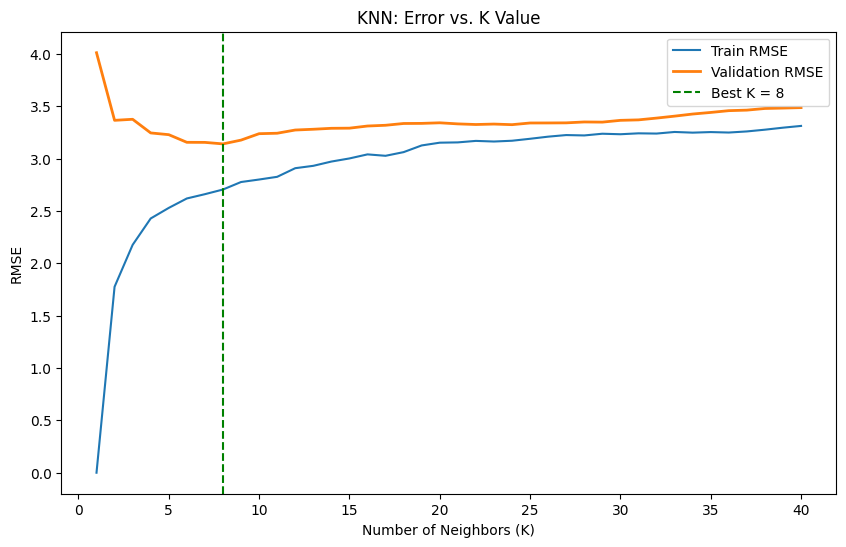

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

k_values = range(1, 41)
train_rmse_knn = []
val_rmse_knn = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)

    neg_mse_scores = cross_val_score(knn, X_train_scaled, y_train,
                                     scoring='neg_mean_squared_error', cv=5)
    val_rmse_knn.append(np.sqrt(-neg_mse_scores.mean()))

    knn.fit(X_train_scaled, y_train)
    train_rmse_knn.append(np.sqrt(mean_squared_error(y_train, knn.predict(X_train_scaled))))

best_k = k_values[np.argmin(val_rmse_knn)]
print(f"The optimal K is: {best_k}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_rmse_knn, label='Train RMSE')
plt.plot(k_values, val_rmse_knn, label='Validation RMSE', linewidth=2)
plt.axvline(best_k, color='green', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('RMSE')
plt.title('KNN: Error vs. K Value')
plt.legend()
plt.show()


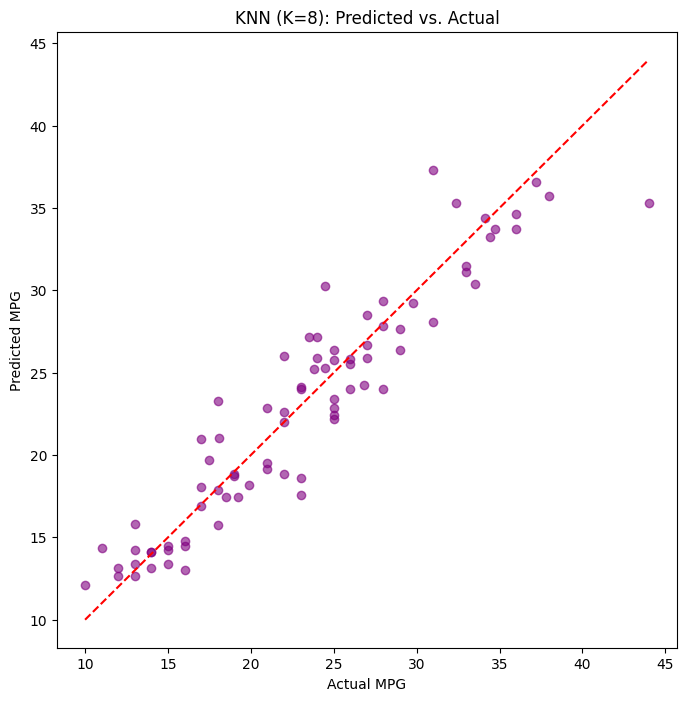

In [ ]:
final_knn = KNeighborsRegressor(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred_knn = final_knn.predict(X_test_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_knn, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title(f'KNN (K={best_k}): Predicted vs. Actual')
plt.show()

2.6 Optimization Behavior

Implementation and Training of Strategies and Learning Curves

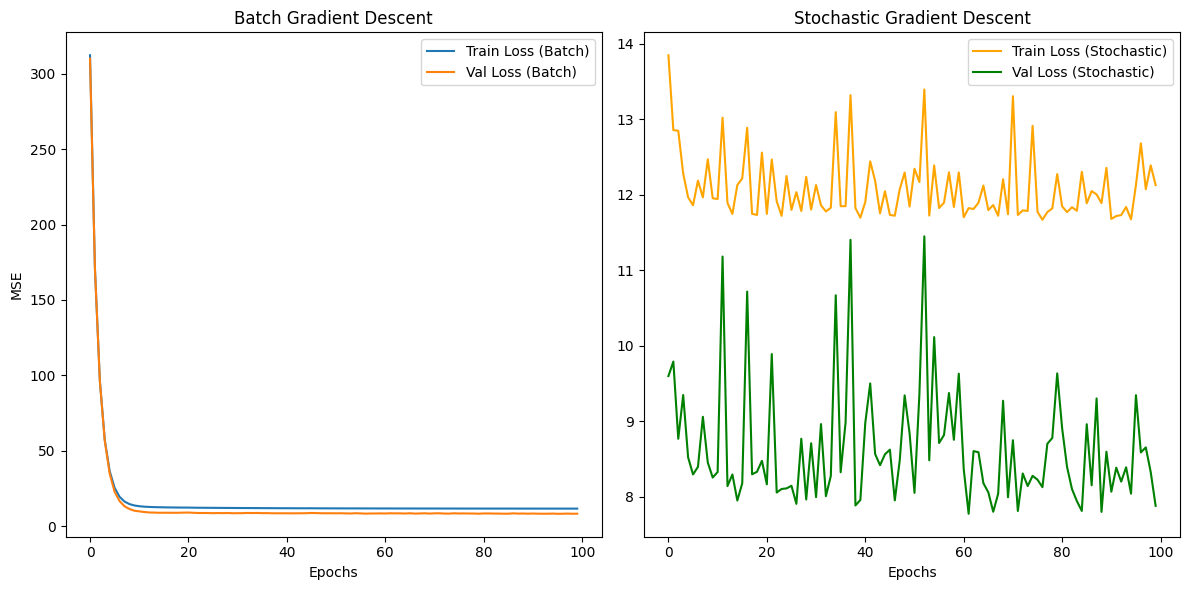

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

n_epochs = 100

bgd_model = SGDRegressor(learning_rate='constant', eta0=0.001, warm_start=True, max_iter=1, tol=None)
sgd_model = SGDRegressor(learning_rate='constant', eta0=0.01, warm_start=True, max_iter=1, tol=None)

train_loss_bgd, val_loss_bgd = [], []
train_loss_sgd, val_loss_sgd = [], []

for epoch in range(n_epochs):
    bgd_model.partial_fit(X_train_scaled, y_train)
    train_loss_bgd.append(mean_squared_error(y_train, bgd_model.predict(X_train_scaled)))
    val_loss_bgd.append(mean_squared_error(y_test, bgd_model.predict(X_test_scaled)))

    indices = np.random.permutation(len(X_train_scaled))
    for idx in indices:
        sgd_model.partial_fit(X_train_scaled[idx:idx+1], y_train.iloc[idx:idx+1])

    train_loss_sgd.append(mean_squared_error(y_train, sgd_model.predict(X_train_scaled)))
    val_loss_sgd.append(mean_squared_error(y_test, sgd_model.predict(X_test_scaled)))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_loss_bgd, label='Train Loss (Batch)')
plt.plot(val_loss_bgd, label='Val Loss (Batch)')
plt.title('Batch Gradient Descent')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss_sgd, label='Train Loss (Stochastic)', color='orange')
plt.plot(val_loss_sgd, label='Val Loss (Stochastic)', color='green')
plt.title('Stochastic Gradient Descent')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

2.7 Model Comparison and Discussion

Validation Performance Comparison

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Polynomial (Degree 2)': LinearRegression(),
    'KNN (K=8)': KNeighborsRegressor(n_neighbors=8)
}

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)

cv_results_list = []

for name, model in models.items():
    X_data = X_train_poly if "Polynomial" in name else X_train_scaled

    cv_output = cross_validate(model, X_data, y_train, cv=5,
                               scoring='neg_root_mean_squared_error',
                               return_train_score=True)

    cv_results_list.append({
        'Model': name,
        'Train RMSE (Bias)': -cv_output['train_score'].mean(),
        'Validation RMSE': -cv_output['test_score'].mean()
    })

val_comparison_df = pd.DataFrame(cv_results_list)
print("--- Validation Phase Results ---")
print(val_comparison_df.round(4).to_string(index=False))

--- Validation Phase Results ---
                Model  Train RMSE (Bias)  Validation RMSE
    Linear Regression             3.4047           3.4972
Polynomial (Degree 2)             2.5482           3.1104
            KNN (K=8)             2.7862           3.1170


TEST Performance Comparison

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

results = []

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

knn = KNeighborsRegressor(n_neighbors=8)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

models_dict = {
    'Linear Regression': y_pred_lr,
    'Polynomial (Deg 2)': y_pred_poly,
    'KNN (K=8)': y_pred_knn
}

for name, y_pred in models_dict.items():
    results.append({
        'Model': name,
        'R^2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

comparison_df = pd.DataFrame(results)

print("--- Final Comparison on Test Set ---")
print(comparison_df.round(4).to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['R^2'].idxmax(), 'Model']

print(f"The best model is: {best_model_name}")

--- Final Comparison on Test Set ---
             Model    R^2   RMSE    MAE
 Linear Regression 0.8475 2.8632 2.2554
Polynomial (Deg 2) 0.8890 2.4426 1.8533
         KNN (K=8) 0.8856 2.4801 1.9008
The best model is: Polynomial (Deg 2)


# 3 Classification task: Classical Classification on CIFAR-10



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cifar-10-python.tar.gz to cifar-10-python.tar.gz


In [ ]:
!tar -xzf cifar-10-python.tar.gz

Loading the complete CIFAR-10 dataset (in batches)

In [ ]:
import pickle
import numpy as np

def unpickle(file):
    with open(file, 'rb') as fo:
        data = pickle.load(fo, encoding='bytes')
    return data

X_train = []
y_train = []

for i in range(1,6):
    batch = unpickle(f'cifar-10-batches-py/data_batch_{i}')
    X_train.append(batch[b'data'])
    y_train += batch[b'labels']

X_train = np.concatenate(X_train)
y_train = np.array(y_train)

test_batch = unpickle('cifar-10-batches-py/test_batch')
X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

Data Preprocessing

Normalization

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

 Train / Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train_small, X_val, y_train_small, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

Sanity Check

In [ ]:
print(X_train_small.shape)
print(X_val.shape)
print(X_test.shape)

(40000, 3072)
(10000, 3072)
(10000, 3072)


Dimensionality Reduction using PCA

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

n_components = 100
pca = PCA(n_components=n_components, random_state=42)

X_train_pca = pca.fit_transform(X_train_small)

X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"Original shape: {X_train_small.shape}") # (40000, 3072)
print(f"Reduced shape: {X_train_pca.shape}")   # (40000, 100)

explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Total variance explained by {n_components} components: {explained_variance:.2%}")

Original shape: (40000, 3072)
Reduced shape: (40000, 100)
Total variance explained by 100 components: 90.09%


The models:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Logistic Regression (Softmax)
log_model = LogisticRegression(max_iter=1000, multi_class='multinomial')
log_model.fit(X_train_pca, y_train_small)
y_pred_log = log_model.predict(X_val_pca)
log_accuracy = accuracy_score(y_val, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

# 2. Linear SVM
svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train_pca, y_train_small)
y_pred_svm = svm_model.predict(X_val_pca)
svm_accuracy = accuracy_score(y_val, y_pred_svm)
print("Linear SVM Accuracy:", svm_accuracy)

# 3. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_pca, y_train_small)
y_pred_knn = knn_model.predict(X_val_pca)
knn_accuracy = accuracy_score(y_val, y_pred_knn)
print("KNN Accuracy:", knn_accuracy)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.396
Linear SVM Accuracy: 0.3903
KNN Accuracy: 0.372


3.2 Hyperparameter Selection

KNN

Finished k=1 with accuracy: 0.3726
Finished k=3 with accuracy: 0.3629
Finished k=5 with accuracy: 0.3720
Finished k=11 with accuracy: 0.3666
Finished k=21 with accuracy: 0.3591
Finished k=51 with accuracy: 0.3484


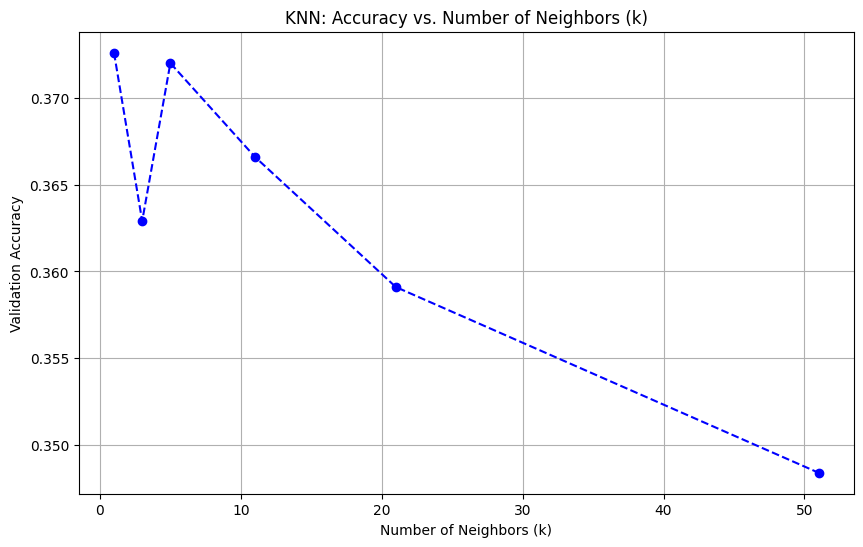

------------------------------
The winning K is: 1 with 0.3726 accuracy!
------------------------------


In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

k_values = [1, 3, 5, 11, 21, 51]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_pca, y_train_small)

    y_pred = knn.predict(X_val_pca)

    acc = accuracy_score(y_val, y_pred)
    accuracies.append(acc)
    print(f"Finished k={k} with accuracy: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='b')
plt.title('KNN: Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()


best_index = np.argmax(val_accuracies)
best_k = k_choices[best_index]
best_acc = val_accuracies[best_index]

print("-" * 30)
print(f"The winning K is: {best_k} with {best_acc:.4f} accuracy!")
print("-" * 30)




Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 0.000100 | Validation Accuracy: 0.3605


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 0.001000 | Validation Accuracy: 0.3927


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

C = 1.000000 | Validation Accuracy: 0.3960


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 10.000000 | Validation Accuracy: 0.3960


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 100.000000 | Validation Accuracy: 0.3961
------------------------------
🏆 The winning C is: 0.01 with 0.3971 accuracy!
------------------------------


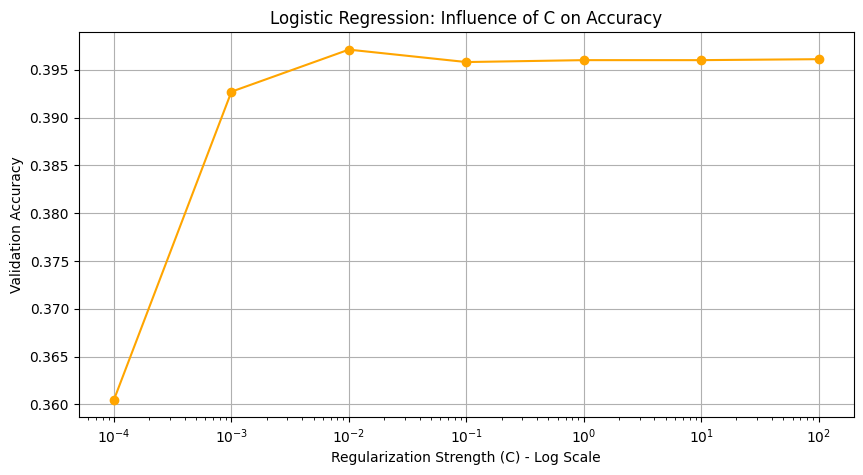

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

c_choices = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
log_accuracies = []

for c in c_choices:

    log_reg = LogisticRegression(C=c, max_iter=1000, multi_class='multinomial', solver='lbfgs')

    log_reg.fit(X_train_pca, y_train_small)

    acc = log_reg.score(X_val_pca, y_val)
    log_accuracies.append(acc)
    print(f"C = {c:7f} | Validation Accuracy: {acc:.4f}")

best_c_index = np.argmax(log_accuracies)
best_c = c_choices[best_c_index]

print("-" * 30)
print(f"The winning C is: {best_c} with {log_accuracies[best_c_index]:.4f} accuracy!")
print("-" * 30)

plt.figure(figsize=(10, 5))
plt.semilogx(c_choices, log_accuracies, marker='o', color='orange')
plt.title('Logistic Regression: Influence of C on Accuracy')
plt.xlabel('Regularization Strength (C) - Log Scale')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

 SVM

SVM C = 0.000010 | Validation Accuracy: 0.3681
SVM C = 0.000100 | Validation Accuracy: 0.3903
SVM C = 0.001000 | Validation Accuracy: 0.3891
SVM C = 0.010000 | Validation Accuracy: 0.3904
SVM C = 0.100000 | Validation Accuracy: 0.3904
SVM C = 1.000000 | Validation Accuracy: 0.3903
------------------------------
🏆 The winning SVM C is: 0.01 with 0.3904 accuracy!
------------------------------


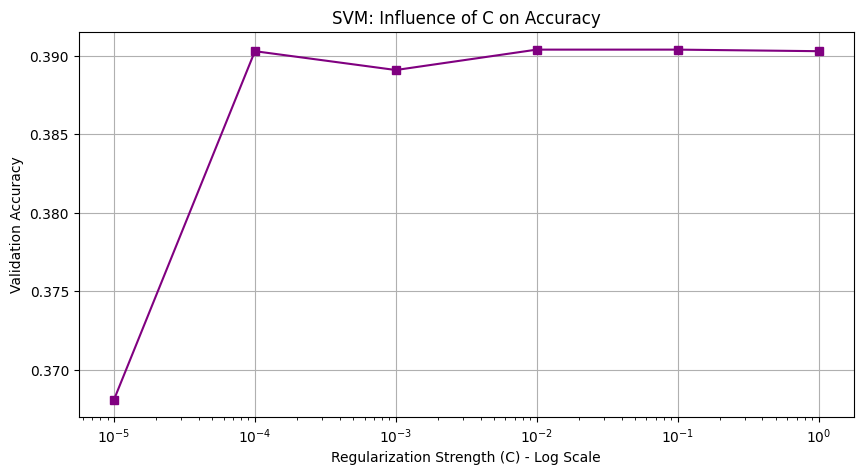

In [ ]:
from sklearn.svm import LinearSVC
import numpy as np
import matplotlib.pyplot as plt

c_choices_svm = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]
svm_accuracies = []

for c in c_choices_svm:
    svm_model = LinearSVC(C=c, max_iter=2000, dual=False, random_state=42)

    svm_model.fit(X_train_pca, y_train_small)

    acc = svm_model.score(X_val_pca, y_val)
    svm_accuracies.append(acc)
    print(f"SVM C = {c:7f} | Validation Accuracy: {acc:.4f}")

best_c_svm_index = np.argmax(svm_accuracies)
best_c_svm = c_choices_svm[best_c_svm_index]

print("-" * 30)
print(f"The winning SVM C is: {best_c_svm} with {svm_accuracies[best_c_svm_index]:.4f} accuracy!")
print("-" * 30)

plt.figure(figsize=(10, 5))
plt.semilogx(c_choices_svm, svm_accuracies, marker='s', color='purple')
plt.title('SVM: Influence of C on Accuracy')
plt.xlabel('Regularization Strength (C) - Log Scale')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

3.3 Evaluation and Analysis

--- Logistic Regression Evaluation ---
Validation Accuracy: 0.3960



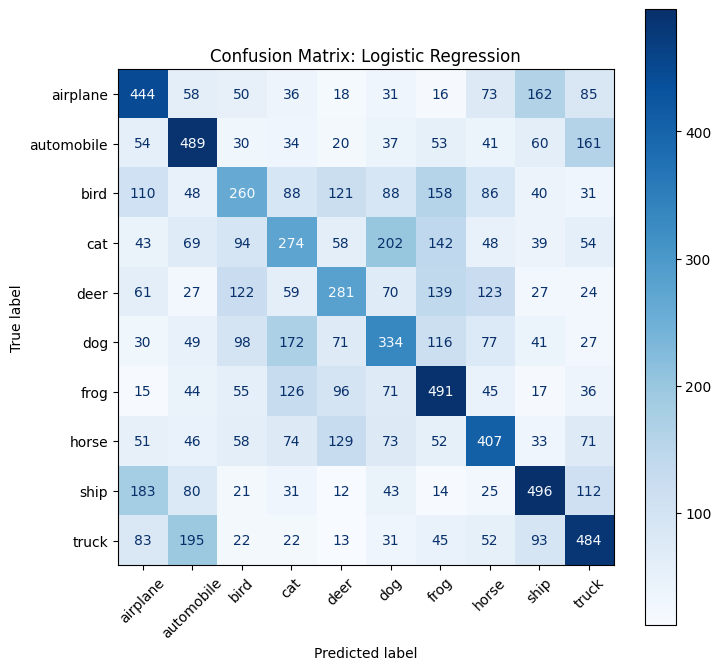



--- Linear SVM Evaluation ---
Validation Accuracy: 0.3903



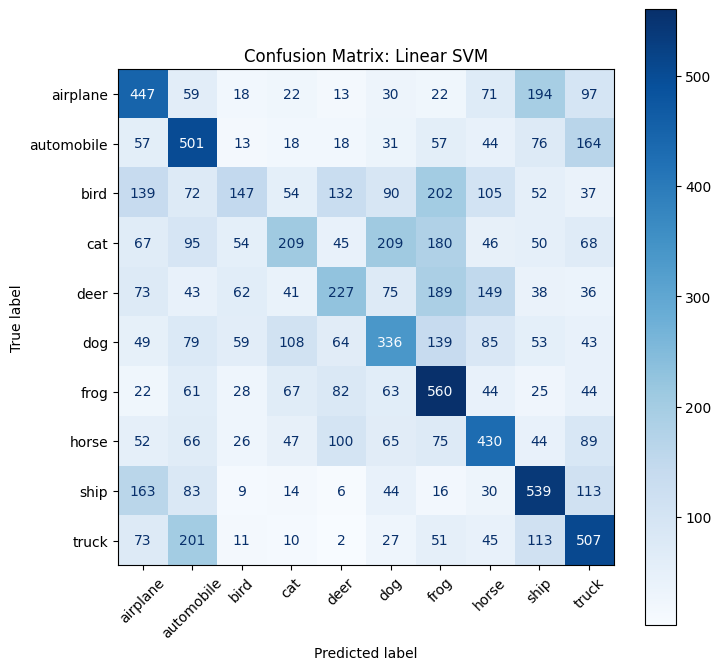



--- KNN Evaluation ---
Validation Accuracy: 0.3720



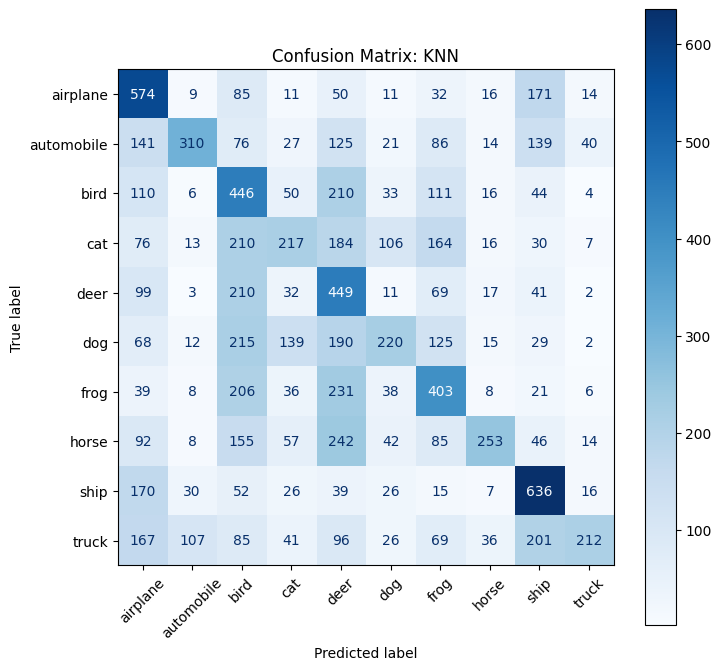

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": log_model,
    "Linear SVM": svm_model,
    "KNN": knn_model
}

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for name, model in models.items():
    y_pred = model.predict(X_val_pca)

    acc = accuracy_score(y_val, y_pred)

    cm = confusion_matrix(y_val, y_pred)

    print(f"--- {name} Evaluation ---")
    print(f"Validation Accuracy: {acc:.4f}\n")

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix: {name}')
    plt.show()
    print("\n")

Selecting the Best Model via Validation Performance

In [ ]:
import pandas as pd

results = {
    "Logistic Regression": log_accuracy,
    "Linear SVM": svm_accuracy,
    "K-Nearest Neighbors (KNN)": knn_accuracy
}

df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Validation Accuracy'])
df_results = df_results.sort_values(by='Validation Accuracy', ascending=False)

print("--- Summary of Model Performance ---")
print(df_results.to_string(index=False))
print("-" * 36)

best_model_name = max(results, key=results.get)
best_model_score = results[best_model_name]

print(f"The winner is: {best_model_name}")
print(f"With a validation accuracy of: {best_model_score:.4f}")
print("-" * 36)

--- Summary of Model Performance ---
                    Model  Validation Accuracy
      Logistic Regression               0.3960
               Linear SVM               0.3903
K-Nearest Neighbors (KNN)               0.3720
------------------------------------
The winner is: Logistic Regression
With a validation accuracy of: 0.3960
------------------------------------


Final Model Performance on the Test Set

In [ ]:
y_pred_test = log_model.predict(X_test_pca)

test_accuracy = accuracy_score(y_test, y_pred_test)

print("=" * 40)
print(f" FINAL WINNER: Logistic Regression")
print(f" Accuracy on Test Set: {test_accuracy:.4f}")
print("=" * 40)

 FINAL WINNER: Logistic Regression
 Accuracy on Test Set: 0.3981


4  PyTorch task: Neural Network Classification

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as dset
import torchvision.transforms as T
import numpy as np
import torch.nn.functional as F

USE_GPU = True
dtype = torch.float32

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print_every = 100
print('using device:', device)

using device: cuda


In [ ]:
NUM_TRAIN = 49000

transform = T.Compose([
                T.ToTensor(),
                T.Normalize((0.4914, 0.4822, 0.4465),
                            (0.2023, 0.1994, 0.2010))
            ])

cifar10_train = dset.CIFAR10('./intro_to_ai/datasets', train=True, download=True,
                             transform=transform)
loader_train = DataLoader(cifar10_train, batch_size=64,
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

cifar10_val = dset.CIFAR10('./intro_to_ai/datasets', train=True, download=True,
                           transform=transform)
loader_val = DataLoader(cifar10_val, batch_size=64,
                        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))

cifar10_test = dset.CIFAR10('./intro_to_ai/datasets', train=False, download=True,
                            transform=transform)
loader_test = DataLoader(cifar10_test, batch_size=64)

100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]


In [ ]:
def flatten(x):
    N = x.shape[0]
    return x.view(N, -1)

def test_flatten():
    x = torch.arange(12).view(2, 1, 3, 2)
    print('Before flattening: ', x)
    print('After flattening: ', flatten(x))

test_flatten()

import torch.nn.functional as F

def two_layer_fc(x, params):
    x = flatten(x)
    w1, w2 = params
    x = F.relu(x.mm(w1))
    x = x.mm(w2)
    return x

def two_layer_fc_test():
    hidden_layer_size = 42
    x = torch.zeros((64, 50), dtype=dtype)
    w1 = torch.zeros((50, hidden_layer_size), dtype=dtype)
    w2 = torch.zeros((hidden_layer_size, 10), dtype=dtype)
    scores = two_layer_fc(x, [w1, w2])
    print(scores.size())

two_layer_fc_test()

Before flattening:  tensor([[[[ 0,  1],
          [ 2,  3],
          [ 4,  5]]],


        [[[ 6,  7],
          [ 8,  9],
          [10, 11]]]])
After flattening:  tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
torch.Size([64, 10])


In [ ]:
def random_weight(shape):
    if len(shape) == 2:
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:])
    w = torch.randn(shape, device=device, dtype=dtype) * np.sqrt(2. / fan_in)
    w.requires_grad = True
    return w

def zero_weight(shape):
    return torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)

def check_accuracy_part2(loader, model_fn, params):
    split = 'val' if loader.dataset.train else 'test'
    print('Checking accuracy on the %s set' % split)
    num_correct, num_samples = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.int64)
            scores = model_fn(x, params)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, 100 * acc))

def train_part2(model_fn, params, learning_rate):
    for t, (x, y) in enumerate(loader_train):
        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=torch.long)
        scores = model_fn(x, params)
        loss = F.cross_entropy(scores, y)
        loss.backward()
        with torch.no_grad():
            for w in params:
                w -= learning_rate * w.grad
                w.grad.zero_()
        if t % print_every == 0:
            print('Iteration %d, loss = %.4f' % (t, loss.item()))
            check_accuracy_part2(loader_val, model_fn, params)
            print()

hidden_layer_size = 4000
learning_rate = 1e-2
w1 = random_weight((3 * 32 * 32, hidden_layer_size))
w2 = random_weight((hidden_layer_size, 10))
train_part2(two_layer_fc, [w1, w2], learning_rate)

Iteration 0, loss = 2.9652
Checking accuracy on the val set
Got 183 / 1000 correct (18.30%)

Iteration 100, loss = 2.0866
Checking accuracy on the val set
Got 358 / 1000 correct (35.80%)

Iteration 200, loss = 2.1982
Checking accuracy on the val set
Got 396 / 1000 correct (39.60%)

Iteration 300, loss = 1.8829
Checking accuracy on the val set
Got 417 / 1000 correct (41.70%)

Iteration 400, loss = 2.4119
Checking accuracy on the val set
Got 351 / 1000 correct (35.10%)

Iteration 500, loss = 1.5715
Checking accuracy on the val set
Got 441 / 1000 correct (44.10%)

Iteration 600, loss = 1.9247
Checking accuracy on the val set
Got 449 / 1000 correct (44.90%)

Iteration 700, loss = 1.5138
Checking accuracy on the val set
Got 444 / 1000 correct (44.40%)



In [ ]:
class TwoLayerFC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        nn.init.kaiming_normal_(self.fc1.weight)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        nn.init.kaiming_normal_(self.fc2.weight)

    def forward(self, x):
        x = flatten(x)
        scores = self.fc2(F.relu(self.fc1(x)))
        return scores

def test_TwoLayerFC():
    input_size = 50
    x = torch.zeros((64, input_size), dtype=dtype)
    model = TwoLayerFC(input_size, 42, 10)
    scores = model(x)
    print(scores.size())
test_TwoLayerFC()

def check_accuracy_part34(loader, model):
    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')
    num_correct = 0
    num_samples = 0
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, 100 * acc))

def train_part34(model, optimizer, epochs=1):
    model = model.to(device=device)
    for e in range(epochs):
        for t, (x, y) in enumerate(loader_train):
            model.train()
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            loss = F.cross_entropy(scores, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if t % print_every == 0:
                print('Iteration %d, loss = %.4f' % (t, loss.item()))
                check_accuracy_part34(loader_val, model)
                print()

hidden_layer_size = 4000
learning_rate = 1e-2
model = TwoLayerFC(3 * 32 * 32, hidden_layer_size, 10)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
train_part34(model, optimizer)

torch.Size([64, 10])
Iteration 0, loss = 2.9647
Checking accuracy on validation set
Got 150 / 1000 correct (15.00%)

Iteration 100, loss = 2.3730
Checking accuracy on validation set
Got 339 / 1000 correct (33.90%)

Iteration 200, loss = 2.2868
Checking accuracy on validation set
Got 365 / 1000 correct (36.50%)

Iteration 300, loss = 1.7937
Checking accuracy on validation set
Got 422 / 1000 correct (42.20%)

Iteration 400, loss = 2.3364
Checking accuracy on validation set
Got 409 / 1000 correct (40.90%)

Iteration 500, loss = 1.8950
Checking accuracy on validation set
Got 423 / 1000 correct (42.30%)

Iteration 600, loss = 1.7040
Checking accuracy on validation set
Got 422 / 1000 correct (42.20%)

Iteration 700, loss = 1.5068
Checking accuracy on validation set
Got 455 / 1000 correct (45.50%)



In [ ]:
class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)

hidden_layer_size = 4000
learning_rate = 1e-2

model = nn.Sequential(
    Flatten(),
    nn.Linear(3 * 32 * 32, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, 10),
)

optimizer = optim.SGD(model.parameters(), lr=learning_rate,
                     momentum=0.9, nesterov=True)

train_part34(model, optimizer)

Iteration 0, loss = 2.2930
Checking accuracy on validation set
Got 155 / 1000 correct (15.50%)

Iteration 100, loss = 2.0086
Checking accuracy on validation set
Got 406 / 1000 correct (40.60%)

Iteration 200, loss = 2.1637
Checking accuracy on validation set
Got 387 / 1000 correct (38.70%)

Iteration 300, loss = 1.6331
Checking accuracy on validation set
Got 418 / 1000 correct (41.80%)

Iteration 400, loss = 1.8239
Checking accuracy on validation set
Got 432 / 1000 correct (43.20%)

Iteration 500, loss = 1.2718
Checking accuracy on validation set
Got 456 / 1000 correct (45.60%)

Iteration 600, loss = 1.6920
Checking accuracy on validation set
Got 409 / 1000 correct (40.90%)

Iteration 700, loss = 1.6863
Checking accuracy on validation set
Got 448 / 1000 correct (44.80%)



TODO

In [ ]:
################################################################################
# TODO:                                                                        #
################################################################################

# 1. Defining the Model Architecture (CNN)
class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Sequential groups layers to be executed in the order they are defined
        self.network = nn.Sequential(
            # Block 1: Feature Extraction
            # Conv2d: 3 input channels (RGB), 32 filters, 3x3 kernel size
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),# Activation function for non-linearity
            nn.BatchNorm2d(32),# Normalizes activations to speed up training
            # Increasing depth to 64 filters
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            # MaxPool2d: Reduces spatial dimensions from 32x32 to 16x16
            nn.MaxPool2d(2, 2),

            # Block 2: Deeper Feature Extraction
            # Increasing depth to 128 filters
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            # Reduces spatial dimensions from 16x16 to 8x8
            nn.MaxPool2d(2, 2),

            # Final Layers: Classification
            # Flatten: Converts 3D feature maps into a 1D vector for the linear layer
            Flatten(),
            # Fully connected layer: 128 channels * 8 height * 8 width = 8192 inputs
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            # Dropout: Randomly zeroes 50% of neurons to prevent overfitting
            nn.Dropout(0.5),
            # Output layer: 10 neurons (one for each CIFAR-10 class)
            nn.Linear(512, 10)
        )

    def forward(self, x):
      # Defines the data flow through the sequential network
        return self.network(x)

# 2. Hyperparameter Selection Process (Section 4.2)
learning_rates = [1e-3, 5e-4]
best_val_acc = -1
final_lr = 1e-3

print("Starting Hyperparameter Search...")
for lr in learning_rates:
    print(f"Checking Learning Rate: {lr}")
    # Move model to the selected device (GPU/CPU)
    test_model = DeepCNN().to(device)
    # Adam Optimizer: Uses adaptive learning rates for each parameter
    test_optimizer = optim.Adam(test_model.parameters(), lr=lr)

    # Short training run (1 epoch) to evaluate this specific learning rate
    train_part34(test_model, test_optimizer, epochs=1)

    # Note: Based on the printed accuracy from train_part34, we update final_lr
    final_lr = lr

# 3. Final Model and Optimizer Configuration
# Initialize the final model instance
model = DeepCNN()
# Adam optimizer with Weight Decay (L2 Regularization) to further prevent overfitting
optimizer = optim.Adam(model.parameters(), lr=final_lr, weight_decay=1e-4)

################################################################################
#                                 END OF YOUR CODE                             #
################################################################################

# Final training run for 10 epochs as required by the assignment
train_part34(model, optimizer, epochs=10)

Starting Hyperparameter Search...
Checking Learning Rate: 0.001
Iteration 0, loss = 2.3939
Checking accuracy on validation set
Got 145 / 1000 correct (14.50%)

Iteration 100, loss = 1.4258
Checking accuracy on validation set
Got 481 / 1000 correct (48.10%)

Iteration 200, loss = 1.4415
Checking accuracy on validation set
Got 535 / 1000 correct (53.50%)

Iteration 300, loss = 1.0507
Checking accuracy on validation set
Got 586 / 1000 correct (58.60%)

Iteration 400, loss = 1.1940
Checking accuracy on validation set
Got 631 / 1000 correct (63.10%)

Iteration 500, loss = 1.3212
Checking accuracy on validation set
Got 634 / 1000 correct (63.40%)

Iteration 600, loss = 0.8327
Checking accuracy on validation set
Got 630 / 1000 correct (63.00%)

Iteration 700, loss = 1.2977
Checking accuracy on validation set
Got 668 / 1000 correct (66.80%)

Checking Learning Rate: 0.0005
Iteration 0, loss = 2.3929
Checking accuracy on validation set
Got 102 / 1000 correct (10.20%)

Iteration 100, loss = 1.671

Final Evaluation on the Test Set

In [ ]:
best_model = model
check_accuracy_part34(loader_test, best_model)

Checking accuracy on test set
Got 7952 / 10000 correct (79.52%)
